In [19]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots

# Aktivace publikačního stylu
plt.style.use(['science', 'nature', 'vibrant'])

# Cesty k souborům (uprav dle potřeby)
DIR = "experiment_direct_max"
WT_PARQUET = f"{DIR}/results_wt.parquet"
META_PARQUET = "../protbert/datasets/dataset_merged_with_families.parquet"

print("⏳ Načítám WT výsledky (souřadnice a clustery)...")
df_wt = pl.read_parquet(WT_PARQUET).select(["original_seq_full", "umap_2d_x", "umap_2d_y", "cluster_id"])

print("⏳ Načítám CATH anotace z původních metadat...")
# Vybereme jen sekvenci a CATH Class (můžeš změnit např. na cath_topology)
df_cath = (
    pl.scan_parquet(META_PARQUET)
    .select(["original_seq_full", "cath_class"])
    .unique(subset=["original_seq_full"])
    .collect()
)

print("🔗 Spojuji data dohromady...")
# Left join - zachováme všechny WT proteiny a přidáme jim CATH, pokud ho mají
df_final = df_wt.join(df_cath, on="original_seq_full", how="left")

# Nahradíme chybějící CATH hodnoty (pokud nějaké jsou) za "Unknown"
df_final = df_final.with_columns(
    pl.col("cath_class").fill_null("Unknown")
)

# Převod do Pandas pro Seaborn
df_plot_pd = df_final.to_pandas()
print(f"✅ Data připravena k vykreslení! Celkem proteinů: {len(df_plot_pd)}")

⏳ Načítám WT výsledky (souřadnice a clustery)...
⏳ Načítám CATH anotace z původních metadat...
🔗 Spojuji data dohromady...
✅ Data připravena k vykreslení! Celkem proteinů: 944


⏳ Načítám WT výsledky a data sources...
📊 Vykresluji 0 standardních bodů a 944 speciálních bodů...


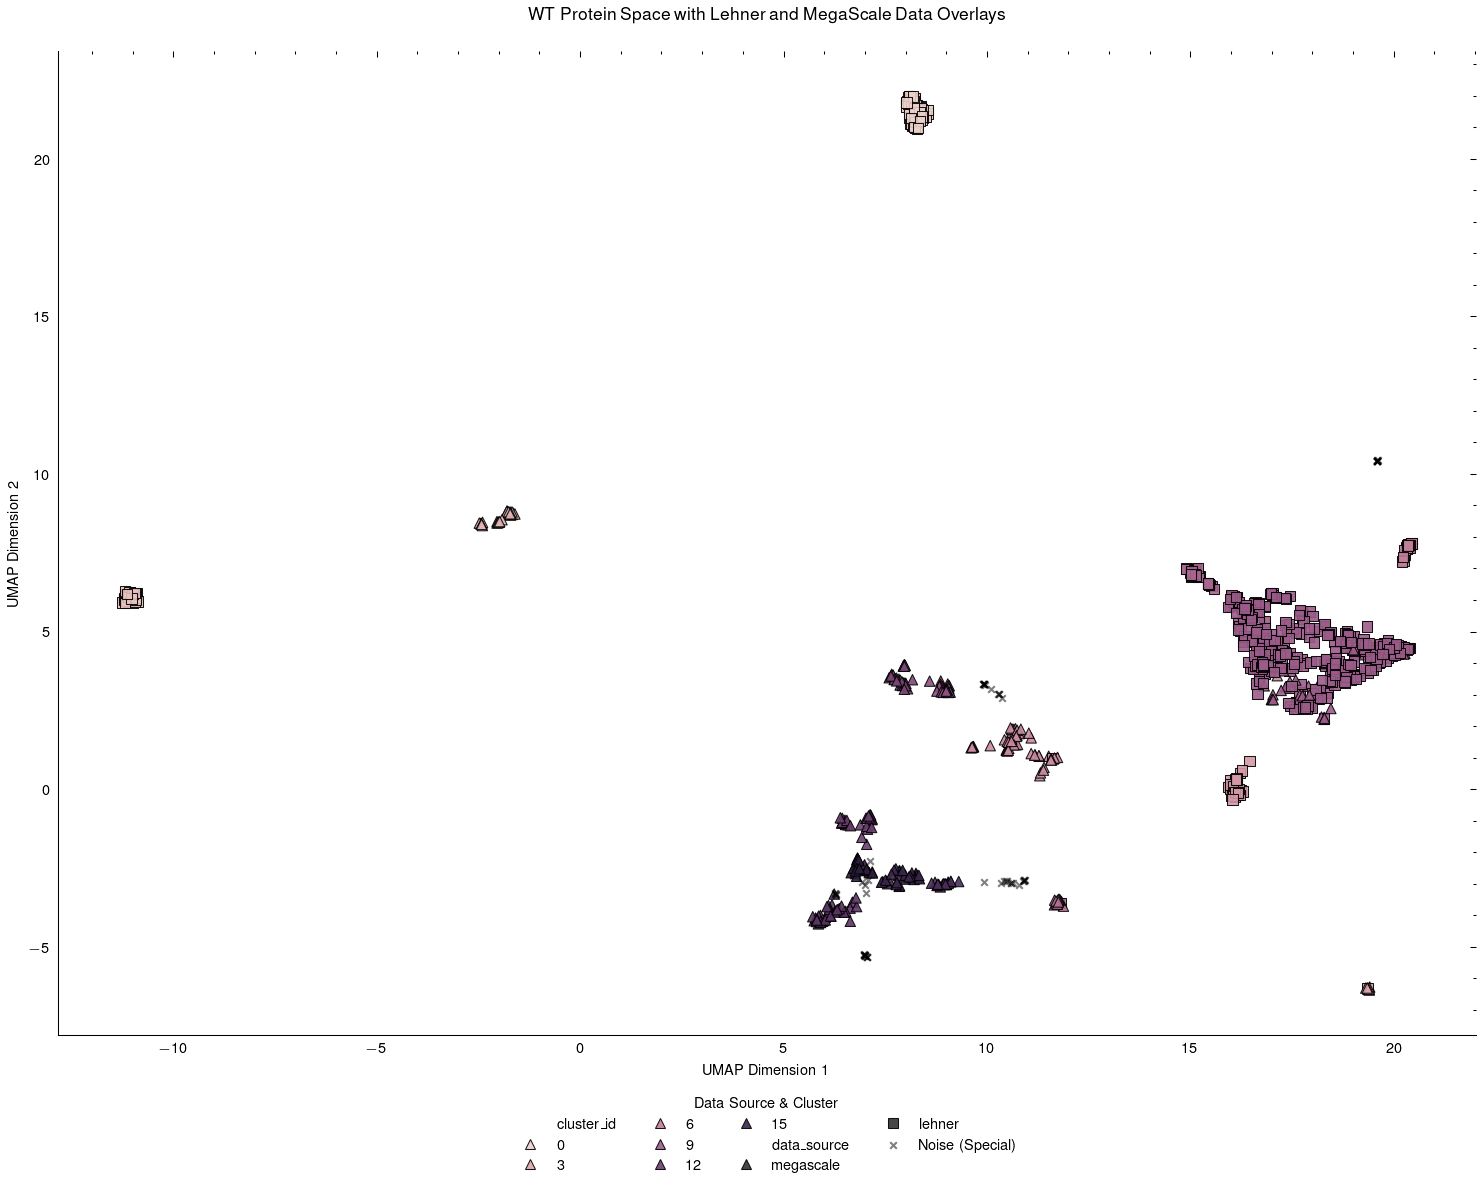

In [25]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

DIR = "experiment_direct_max"
WT_PARQUET = f"{DIR}/results_wt.parquet"
META_PARQUET = "../protbert/datasets/dataset_merged_with_families.parquet"

print("⏳ Načítám WT výsledky a data sources...")
# Načteme výsledky klastrování a spojíme se zdrojem dat z metadat
df_final = (
    pl.scan_parquet(WT_PARQUET)
    .select(["original_seq_full", "umap_2d_x", "umap_2d_y", "cluster_id"])
    .join(
        pl.scan_parquet(META_PARQUET).select(["original_seq_full", "data_source"]).unique(),
        on="original_seq_full", how="inner"
    )
    .collect()
    .to_pandas()
)

# Definujeme, která data sources chceme zvýraznit
special_sources = ["lehner", "megascale"]
df_special = df_final[df_final['data_source'].isin(special_sources)]
df_others = df_final[~df_final['data_source'].isin(special_sources)]

print(f"📊 Vykresluji {len(df_others)} standardních bodů a {len(df_special)} speciálních bodů...")

# Vytvoření grafu
fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

# 1. Vrstva: Obecný kontext WT dat (šedě)
ax.scatter(
    df_others['umap_2d_x'], df_others['umap_2d_y'],
    color='lightgrey', s=2, alpha=0.3, zorder=1
)

# 2. Vrstva: Zvýrazněné clustery (barevně)
sns.scatterplot(
    data=df_special[df_special['cluster_id'] != -1],
    x='umap_2d_x', y='umap_2d_y',
    hue='cluster_id',
    style='data_source',
    markers={'lehner': 's', 'megascale': '^'}, # s=square, ^=triangle
    s=25, alpha=0.9,
    edgecolor='black', linewidth=0.5,
    zorder=2,
    ax=ax
)

# 3. Vrstva: Šum pro speciální sources (černý křížek)
df_special_noise = df_special[df_special['cluster_id'] == -1]
ax.scatter(
    df_special_noise['umap_2d_x'], df_special_noise['umap_2d_y'],
    color='black', marker='x', s=10, alpha=0.5, zorder=3, label='Noise (Special)'
)

# ==========================================
# 4. Vyladění legendy (PŘESUN POD GRAF)
# ==========================================
ax.legend(
    title=r"Data Source \& Cluster",
    bbox_to_anchor=(0.5, -0.05),  # 0.5 = horizontální střed, -0.15 = posun pod osu X
    loc='upper center',           # Kotvíme za horní střed boxu legendy
    ncol=4,                       # Rozdělí položky do 4 sloupců vedle sebe (můžeš upravit dle libosti)
    frameon=False                 # Odstraní ošklivý rámeček (volitelné, v scienceplots vypadá lépe bez něj)
)

ax.set_title("WT Protein Space with Lehner and MegaScale Data Overlays", pad=15, fontweight='bold')
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")

# Odstranění horního a pravého okraje
sns.despine()

# Přidáme malý padding, aby se legenda dole neusekla při ukládání
plt.tight_layout()
plt.savefig("wt_cath_clusters_science_lehner_vs_megascale.pdf", bbox_inches='tight')
plt.show()

In [28]:
import pandas as pd
import seaborn as sns
import re

print("⏳ Generuji MASTERPIECE tabulku (Barvy, Tvary, Tučné písmo)...")

# 1. Vytvoření kontingenční tabulky
crosstab = pd.crosstab(
    index=df_plot_pd['cluster_id'],
    columns=df_plot_pd['cath_class'],
    margins=True,
    margins_name="Celkem"
)

# 2. Kosmetika
if -1 in crosstab.index:
    crosstab = crosstab.rename(index={-1: "Šum (-1)"})
    ostatni_clustery = [i for i in crosstab.index if i not in ["Šum (-1)", "Celkem"]]
    nove_poradi = ostatni_clustery + ["Šum (-1)", "Celkem"]
    crosstab = crosstab.loc[nove_poradi]

# 3. PŘÍPRAVA DAT (Tučné písmo)
latex_df = crosstab.copy().astype(str)

for row_idx in crosstab.index:
    if row_idx == 'Celkem': continue
    cols_to_check = [c for c in crosstab.columns if c != 'Celkem']
    max_val = crosstab.loc[row_idx, cols_to_check].max()

    if max_val > 0:
        for col in cols_to_check:
            if crosstab.loc[row_idx, col] == max_val:
                latex_df.loc[row_idx, col] = f"BOLDSTART{int(max_val)}BOLDEND"

# 4. PLACEHOLDERY PRO SYMBOLY CATH RODIN (do názvů sloupců)
cath_placeholders = {
    "G3DSA:1": "SYM_ALPHA G3DSA:1",
    "G3DSA:2": "SYM_BETA G3DSA:2",
    "G3DSA:3": "SYM_ALPHABETA G3DSA:3",
    "G3DSA:4": "SYM_FEW G3DSA:4",
    "G3DSA:6": "SYM_SPEC G3DSA:6",
    "Unknown": "SYM_UNK Unknown",
    "Celkem": "Celkem"
}
# Aplikujeme jen na ty sloupce, které v datech reálně existují
valid_cath_placeholders = {k: v for k, v in cath_placeholders.items() if k in latex_df.columns}
latex_df.rename(columns=valid_cath_placeholders, inplace=True)

# 5. PLACEHOLDERY PRO BARVY CLUSTERŮ (do názvů řádků)
hex_colors = sns.color_palette("tab20").as_hex()
row_placeholders = {}

for idx in latex_df.index:
    if idx == "Celkem":
        row_placeholders[idx] = "Celkem"
    elif idx == "Šum (-1)":
        row_placeholders[idx] = "COLOR_NOISE Šum (-1)"
    else:
        # Vytáhneme přesnou Hex barvu ze Seaborn palety (bez mřížky, velkými písmeny)
        c_id = int(idx)
        hex_c = hex_colors[c_id % 20][1:].upper()
        row_placeholders[idx] = f"COLOR_{hex_c} Cluster {idx}"

latex_df.rename(index=row_placeholders, inplace=True)

# 6. Vygenerování kódu přes Pandas
latex_code = latex_df.style.to_latex(
    caption="Distribuce strukturních rodin CATH v HDBSCAN shlucích. Barvy a tvary plně odpovídají 2D UMAP vizualizaci.",
    label="tab:cath_clusters_colors",
    hrules=True,
    column_format="l" + "c" * len(latex_df.columns)
)

# 7. VELKÉ NAHRAZOVÁNÍ (Náš neprůstřelný hack)
# Tučné písmo
latex_code = latex_code.replace("BOLDSTART", "\\textbf{").replace("BOLDEND", "}")

# Symboly CATH
latex_code = latex_code.replace("SYM_ALPHA", "$\\bullet$")             # Kolečko
latex_code = latex_code.replace("SYM_BETA", "$\\blacksquare$")         # Čtvereček
latex_code = latex_code.replace("SYM_ALPHABETA", "$\\blacktriangle$")  # Trojúhelník
latex_code = latex_code.replace("SYM_FEW", "$\\blacklozenge$")         # Kosočtverec
latex_code = latex_code.replace("SYM_SPEC", "$\\blacktriangledown$")   # Troj. dolů
latex_code = latex_code.replace("SYM_UNK", "$\\times$")                # Křížek

# Barvy Clusterů
latex_code = latex_code.replace("COLOR_NOISE", "\\textcolor[HTML]{D3D3D3}{\\ensuremath{\\blacksquare}}") # Světle šedý čtvereček pro šum
latex_code = re.sub(r"COLOR_([A-F0-9]{6})", r"\\textcolor[HTML]{\1}{\\ensuremath{\\blacksquare}}", latex_code)

print("\n" + "="*70)
print("📄 ZKOPÍRUJ SI TENTO KÓD (Vizuální dokonalost zaručena):")
print("="*70)
print(latex_code)

⏳ Generuji MASTERPIECE tabulku (Barvy, Tvary, Tučné písmo)...

📄 ZKOPÍRUJ SI TENTO KÓD (Vizuální dokonalost zaručena):
\begin{table}
\caption{Distribuce strukturních rodin CATH v HDBSCAN shlucích. Barvy a tvary plně odpovídají 2D UMAP vizualizaci.}
\label{tab:cath_clusters_colors}
\begin{tabular}{lcccccc}
\toprule
cath_class & $\bullet$ G3DSA:1 & $\blacksquare$ G3DSA:2 & $\bullet$BETA G3DSA:3 & $\blacklozenge$ G3DSA:4 & $\blacktriangledown$ G3DSA:6 & Celkem \\
cluster_id &  &  &  &  &  &  \\
\midrule
\textcolor[HTML]{1F77B4}{\ensuremath{\blacksquare}} Cluster 0 & 21 & \textbf{26} & 23 & 0 & 0 & 70 \\
\textcolor[HTML]{AEC7E8}{\ensuremath{\blacksquare}} Cluster 1 & \textbf{22} & 18 & 8 & 1 & 0 & 49 \\
\textcolor[HTML]{FF7F0E}{\ensuremath{\blacksquare}} Cluster 2 & \textbf{11} & 9 & \textbf{11} & 1 & 0 & 32 \\
\textcolor[HTML]{FFBB78}{\ensuremath{\blacksquare}} Cluster 3 & \textbf{8} & 2 & 5 & 0 & 0 & 15 \\
\textcolor[HTML]{2CA02C}{\ensuremath{\blacksquare}} Cluster 4 & 10 & \textbf{16} &

In [10]:
import polars as pl

DIR = "experiment_direct_max"
WT_PARQUET = f"{DIR}/results_wt.parquet"
MUT_PARQUET = f"{DIR}/results_mut.parquet"
META_PARQUET = "../protbert/datasets/dataset_merged_with_families.parquet"

print("⏳ 1. Vytvářím mapovací most včetně skóre 'target'...")
# Přidali jsme načtení 'target' a ponechali ho ve finálním výběru
df_bridge = (
    pl.scan_parquet(META_PARQUET)
    .select(["original_seq_full", "mutated_seq_full", "reverse", "target"])
    .with_columns([
        pl.when(pl.col("reverse") == True)
        .then(pl.col("mutated_seq_full"))
        .otherwise(pl.col("original_seq_full"))
        .alias("true_wt_seq"),

        pl.when(pl.col("reverse") == True)
        .then(pl.col("original_seq_full"))
        .otherwise(pl.col("mutated_seq_full"))
        .alias("true_mut_seq")
    ])
    .select(["true_wt_seq", "true_mut_seq", "target"]) # <--- ZDE držíme target!
    .unique()
)

print("⏳ 2. Připojuji WT a Mutant clustery...")
df_wt_lazy = (
    pl.scan_parquet(WT_PARQUET)
    .select([pl.col("original_seq_full").alias("true_wt_seq"), pl.col("cluster_id").alias("wt_cluster")])
    .unique(subset=["true_wt_seq"])
)
df_mut_lazy = (
    pl.scan_parquet(MUT_PARQUET)
    .select([pl.col("original_seq_full").alias("true_mut_seq"), pl.col("cluster_id").alias("mut_cluster")])
    .unique(subset=["true_mut_seq"])
)

df_mapped_wt = df_bridge.join(df_wt_lazy, on="true_wt_seq", how="inner")
df_final_join = df_mapped_wt.join(df_mut_lazy, on="true_mut_seq", how="inner")

print("⏳ 3. Klasifikuji přechody a počítám statistiky funkčního skóre...\n")
df_detailed = (
    df_final_join.with_columns([
        pl.when((pl.col("wt_cluster") == pl.col("mut_cluster")) & (pl.col("wt_cluster") != -1))
        .then(pl.lit("Stabilní"))

        .when((pl.col("wt_cluster") != -1) & (pl.col("mut_cluster") == -1))
        .then(pl.lit("Do šumu"))

        .when((pl.col("wt_cluster") != -1) & (pl.col("mut_cluster") != -1) & (pl.col("wt_cluster") != pl.col("mut_cluster")))
        .then(pl.lit("Skokan"))

        .otherwise(pl.lit("Ostatní"))
        .alias("Kategorie")
    ])
    .collect()
)

print("="*80)
print("🚀 TOP 10: SKOKANI (Změna struktury) a jejich funkční dopad")
print("="*80)
df_skokani = (
    df_detailed.filter(pl.col("Kategorie") == "Skokan")
    .group_by(["wt_cluster", "mut_cluster"])
    .agg([
        pl.len().alias("Počet mutantů"),
        pl.col("target").mean().round(3).alias("Průměrný target"),
        pl.col("target").median().round(3).alias("Medián target")
    ])
    .sort("Počet mutantů", descending=True)
    .head(10)
    .rename({"wt_cluster": "Původní WT Cluster", "mut_cluster": "Nový Mutant Cluster"})
)
display(df_skokani)

print("\n" + "="*80)
print("🛡️ TOP 10: STABILNÍ CLUSTERY (Zachována struktura) a jejich funkční dopad")
print("="*80)
df_stabilni = (
    df_detailed.filter(pl.col("Kategorie") == "Stabilní")
    .group_by("wt_cluster")
    .agg([
        pl.len().alias("Počet mutantů"),
        pl.col("target").mean().round(3).alias("Průměrný target"),
        pl.col("target").median().round(3).alias("Medián target")
    ])
    .sort("Počet mutantů", descending=True)
    .head(10)
    .rename({"wt_cluster": "WT Cluster"})
)
display(df_stabilni)

print("\n" + "="*80)
print("💥 TOP 10: KŘEHKÉ CLUSTERY (Pád do šumu) a jejich funkční dopad")
print("="*80)
df_sum = (
    df_detailed.filter(pl.col("Kategorie") == "Do šumu")
    .group_by("wt_cluster")
    .agg([
        pl.len().alias("Počet mutantů"),
        pl.col("target").mean().round(3).alias("Průměrný target"),
        pl.col("target").median().round(3).alias("Medián target")
    ])
    .sort("Počet mutantů", descending=True)
    .head(10)
    .rename({"wt_cluster": "Původní WT Cluster"})
)
display(df_sum)

⏳ 1. Vytvářím mapovací most včetně skóre 'target'...
⏳ 2. Připojuji WT a Mutant clustery...
⏳ 3. Klasifikuji přechody a počítám statistiky funkčního skóre...

🚀 TOP 10: SKOKANI (Změna struktury) a jejich funkční dopad


Původní WT Cluster,Nový Mutant Cluster,Počet mutantů,Průměrný target,Medián target
i32,i32,u32,f64,f64
9,6,16186,0.083,0.0
9,4,3334,0.092,0.0
5,9,1454,0.089,0.0
2,16,1166,0.0,0.0
14,15,1032,0.0,0.0
5,4,794,0.0,0.0
5,16,302,0.0,0.0
6,9,256,0.0,0.0
4,9,250,0.083,0.001



🛡️ TOP 10: STABILNÍ CLUSTERY (Zachována struktura) a jejich funkční dopad


WT Cluster,Počet mutantů,Průměrný target,Medián target
i32,u32,f64,f64
9,757934,0.082,0.0
5,84492,0.0,0.0
8,69568,0.098,0.0
13,61954,0.0,0.0
10,51176,-0.0,0.0
15,45882,-0.0,0.0
12,44334,-0.0,0.0
16,42216,-0.0,0.0
11,38946,-0.0,0.0



💥 TOP 10: KŘEHKÉ CLUSTERY (Pád do šumu) a jejich funkční dopad


Původní WT Cluster,Počet mutantů,Průměrný target,Medián target
i32,u32,f64,f64
14,3962,-0.0,0.0
16,3950,-0.0,0.0
13,3628,-0.0,0.0
15,3342,0.0,0.0
12,2228,-0.0,0.0
9,1492,0.037,0.0
5,504,-0.0,0.0
2,132,0.0,0.0
